🚀 Loan Risk Prediction with Machine Learning
💳 Can We Predict Loan Default Risk Accurately?

Financial institutions face significant losses due to loan defaults.
In this project, we build a robust Loan Risk Classification model to predict whether a borrower is likely to default or not.

📊 Dataset

We use the publicly available Kaggle dataset:

🔗 Loan Risk Prediction Dataset
https://www.kaggle.com/datasets/sohailkhan05/loan-risk-prediction/data

The dataset includes borrower-related features such as:

👤 Demographic information

💰 Income & employment details

🏠 Home ownership status

📈 Loan characteristics

⚠️ Default label (Target Variable)

🧠 Project Objective

The main goal is to:

Build a baseline model

Improve performance using advanced ML techniques

Optimize classification threshold

Interpret the model using feature importance & SHAP

Evaluate business impact with cost-sensitive analysis

⚙️ Modeling Approach

✔️ Data Cleaning & Outlier Handling
✔️ Missing Value Imputation
✔️ Feature Engineering
✔️ Encoding Strategies
✔️ Baseline Logistic Regression
✔️ Gradient Boosting (LightGBM)
✔️ Hyperparameter Optimization
✔️ Threshold Optimization (F1 / Precision-Recall Balance)
✔️ Model Explainability (SHAP)

📈 Evaluation Metrics

Since this is a risk prediction problem, we focus on:

ROC-AUC

Precision

Recall

F1-Score

Business Cost Analysis

We especially analyze the Precision-Recall trade-off, as missing risky borrowers (False Negatives) has high financial cost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

At the beginning of the project, I imported the core libraries for data analysis. NumPy and Pandas will handle data processing, while Matplotlib and Seaborn are used for visualization. I also suppressed unnecessary warnings to keep the output clean.

In [2]:
df = pd.read_csv('loan_risk_prediction_dataset.csv')

print(df.shape)
print(df.info())
print(df.isnull().sum().sort_values(ascending=False))
df.describe()

(5000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
None
Education          198
Income             196
CreditScore        194
Age                  0
LoanAmount           0
YearsExperience      0
Gender               0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


After loading the dataset, I first checked its shape and data types. The overall structure looks clean, but I noticed missing values mainly in Education, Income, and CreditScore.

In [3]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [4]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')

In [5]:
def visualize_data(df, cat_limit=20):
    sns.set_style("whitegrid")
    sns.set_palette("muted")

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

    print(f"Numerical: {len(num_cols)} | Categorical: {len(cat_cols)} variables\n")

    for col in num_cols:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Numerical: {col}", fontsize=14, fontweight='bold')

        sns.histplot(df[col], kde=True, ax=ax1, color='skyblue')
        ax1.set(title="Distribution", xlabel=col, ylabel="Frequency")

        sns.boxplot(x=df[col], ax=ax2, color='lightgreen')
        ax2.set(title="Outliers", xlabel=col)

        plt.tight_layout()
        plt.show()

    for col in cat_cols:
        if df[col].nunique() > cat_limit:
            print(f"⚠️ '{col}' skipped ({df[col].nunique()} unique values > limit {cat_limit})")
            continue

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            hue=col,
            palette="viridis",
            legend=False,
            ax=ax
        )

        ax.set(title=f"Categorical: {col}", xlabel=col, ylabel="Count")
        ax.bar_label(ax.containers[0])
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    print("Completed.")

Numerical: 6 | Categorical: 4 variables



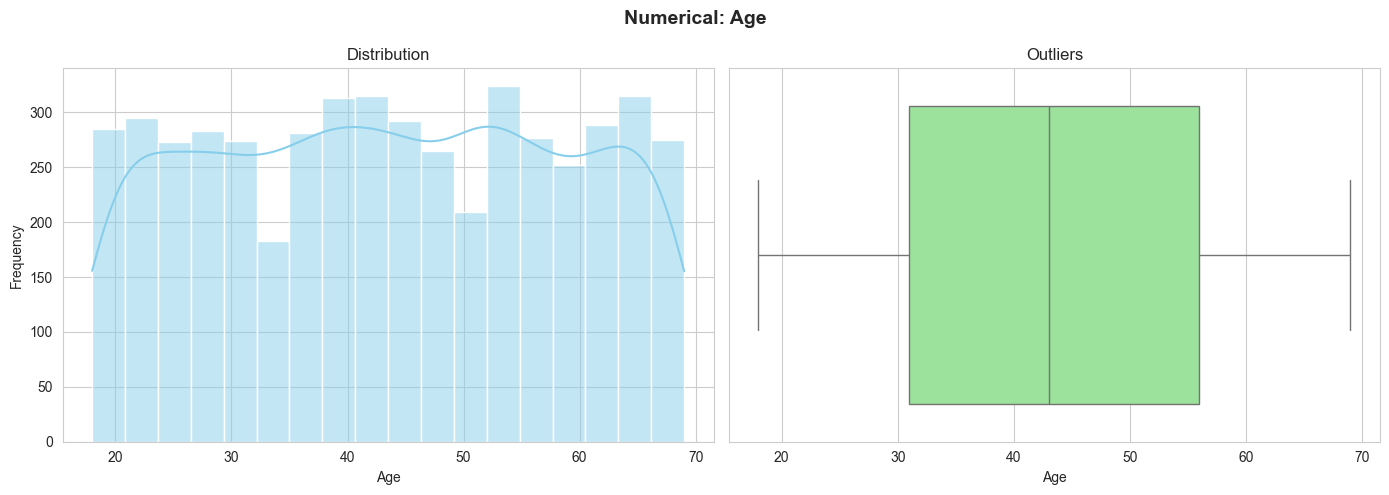

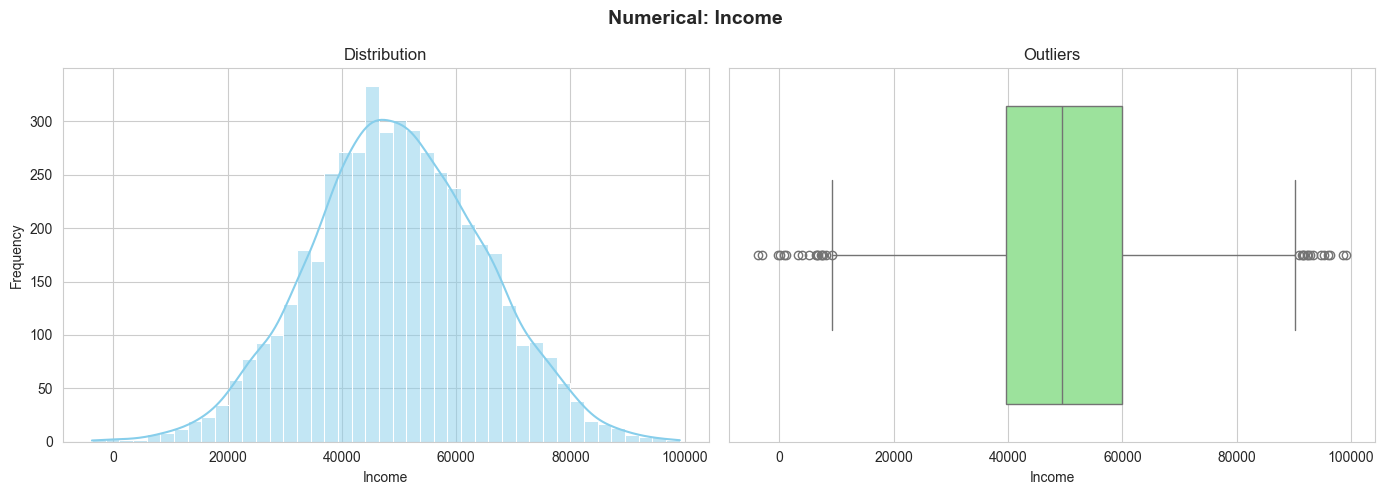

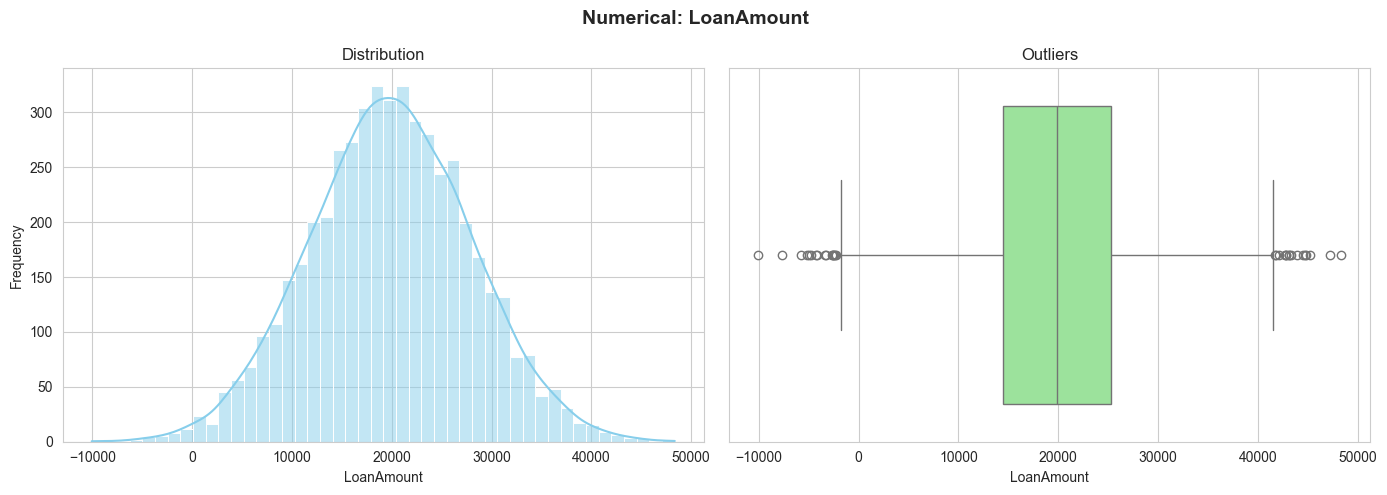

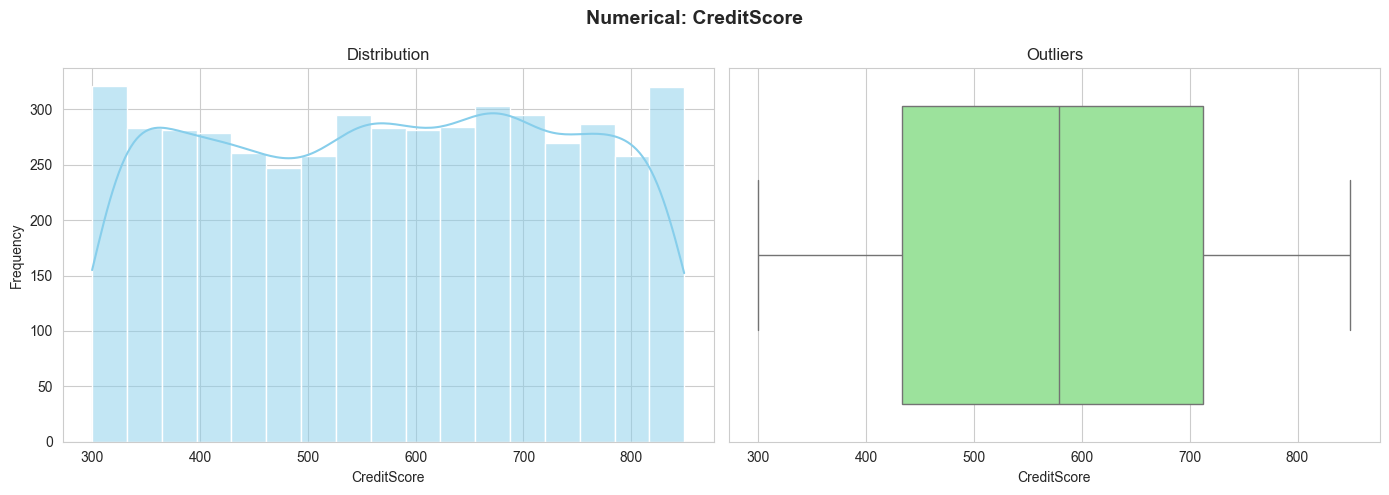

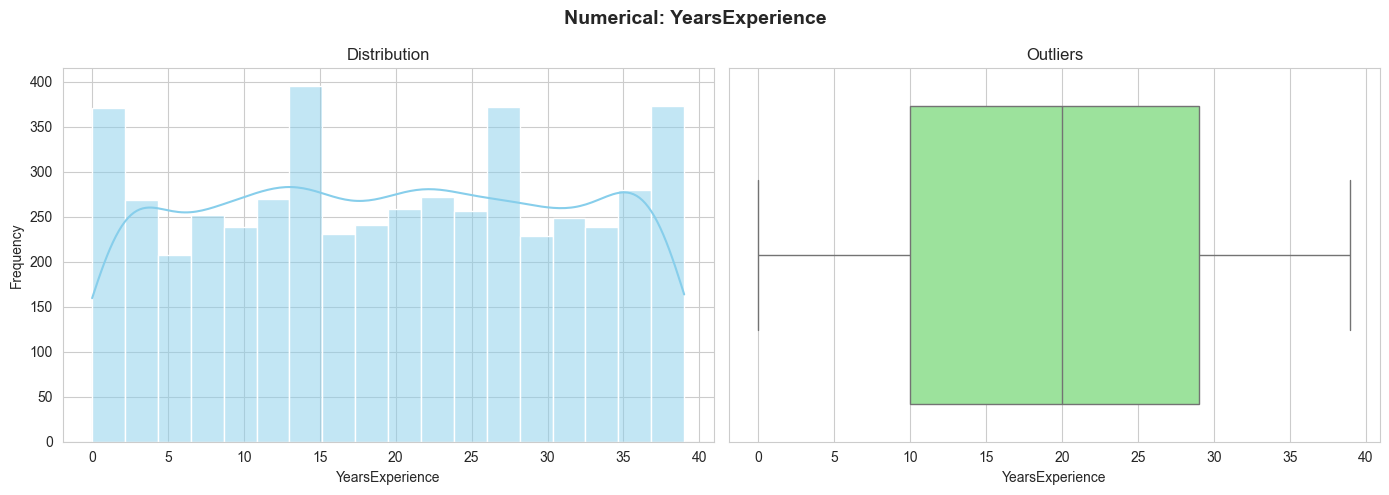

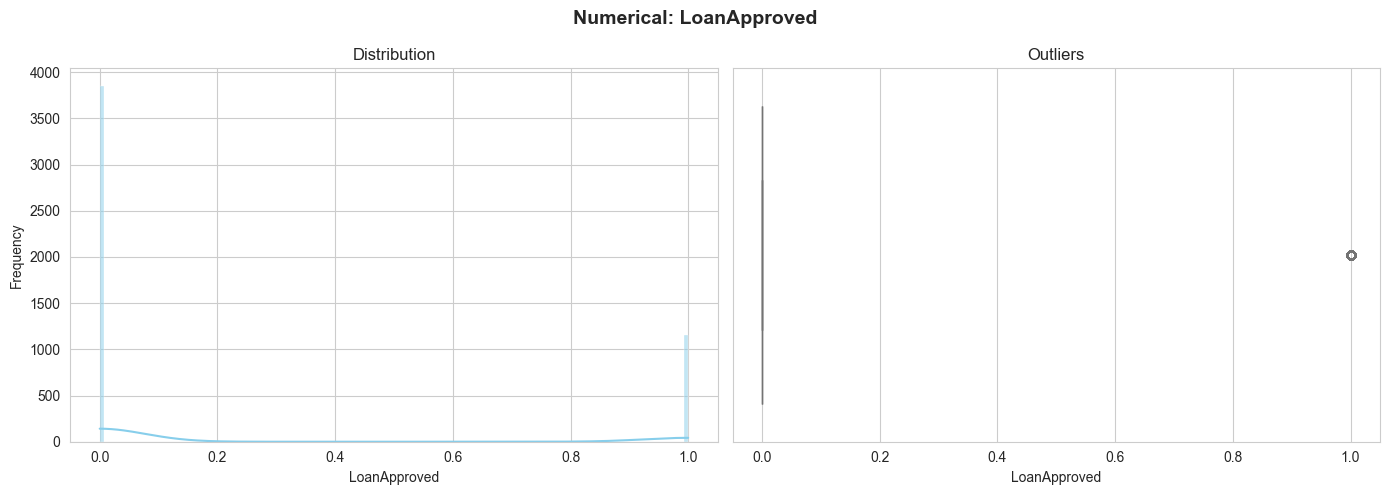

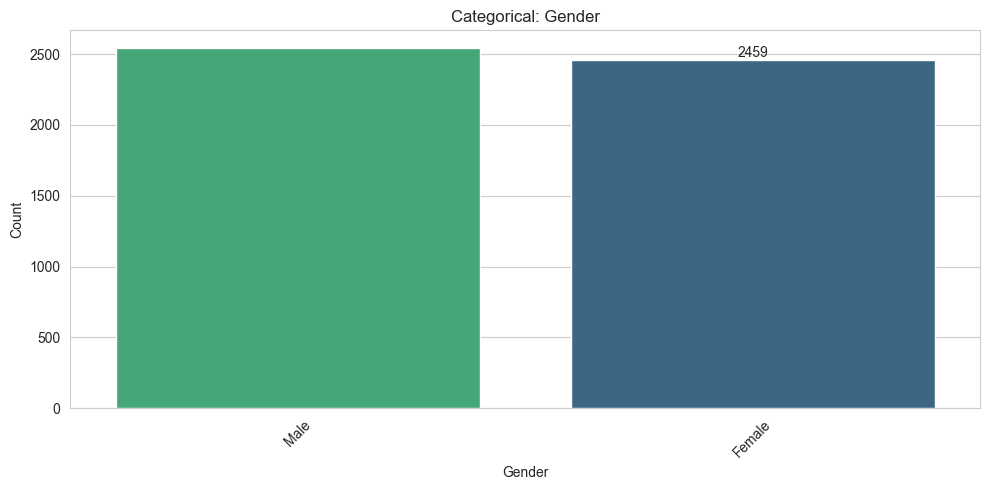

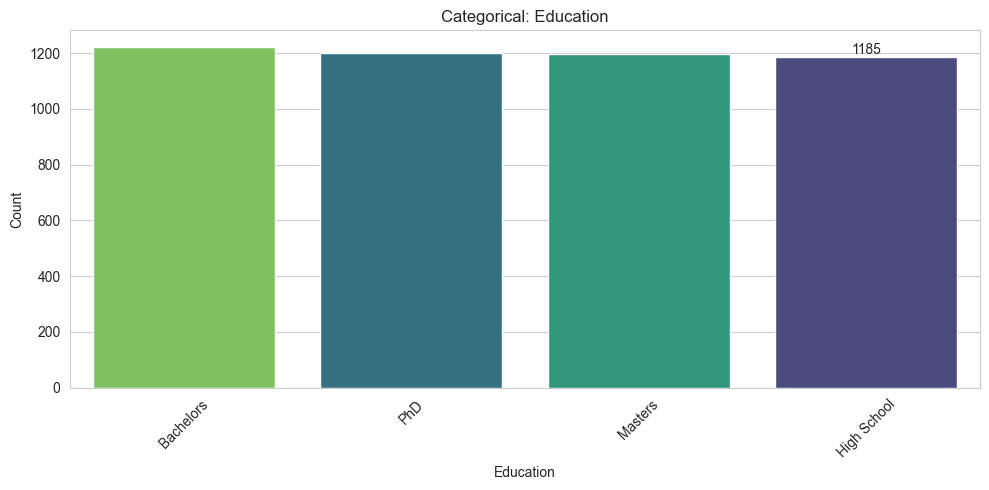

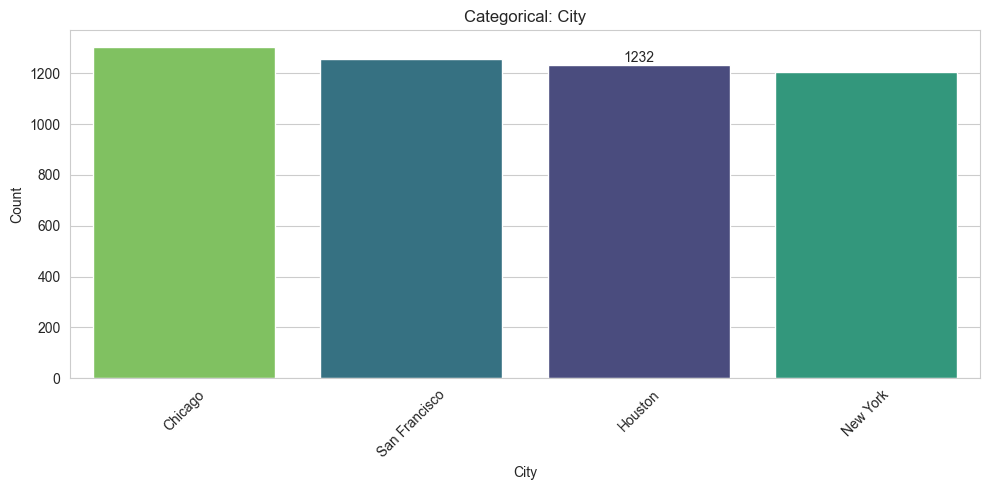

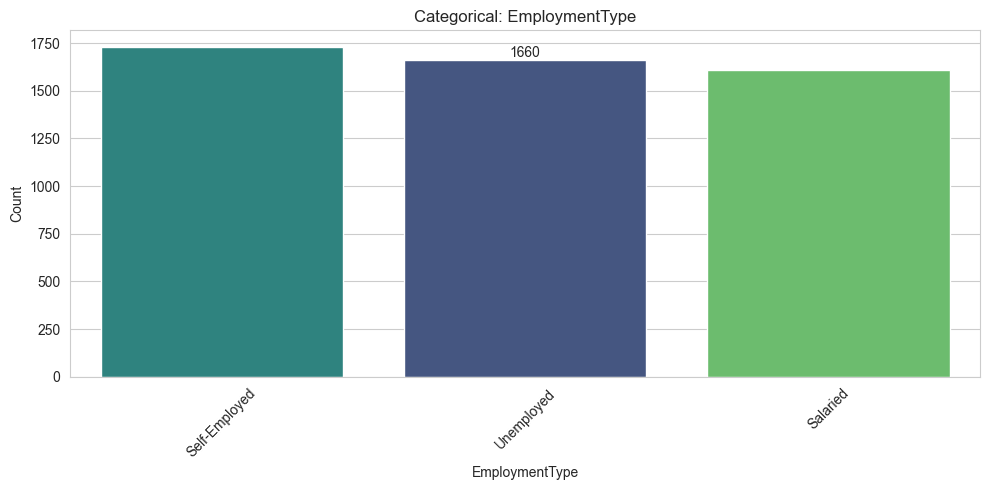

Completed.


In [6]:
visualize_data(df)

To better understand the dataset, I examined the distribution and outliers of all numerical variables using histograms and boxplots. Most numerical features appear to be approximately normally distributed.

For categorical variables, I checked the class distributions. I noticed that the target variable is not perfectly balanced. Since class imbalance can affect model performance, I will need to consider this issue in the modeling stage.

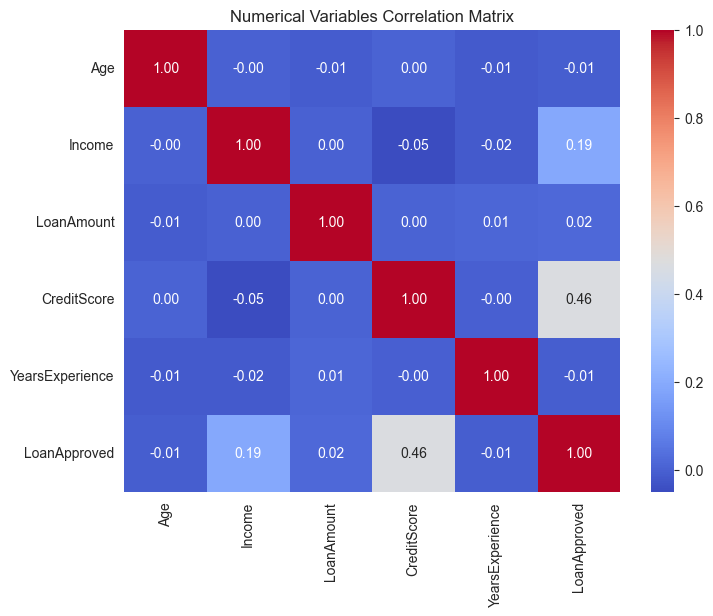

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Variables Correlation Matrix")
plt.show()

When I examined the correlation matrix, I did not observe any strong multicollinearity among the numerical variables. Most features have weak relationships with each other.

The most noticeable relationship with the target variable appears to be CreditScore. It shows a moderate positive correlation, suggesting that credit score plays an important role in loan approval decisions.

In [8]:
# Select object-type columns
obj_cols = df.select_dtypes(include='object').columns

# Print unique values for each categorical column
for col in obj_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Gender:
['Female' 'Male']

Unique values in Education:
['High School' 'PhD' nan 'Masters' 'Bachelors']

Unique values in City:
['Houston' 'San Francisco' 'New York' 'Chicago']

Unique values in EmploymentType:
['Unemployed' 'Self-Employed' 'Salaried']


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

In [10]:
class AgeGroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Age bins: 18–25, 26–35, 36–50, 51–69
        self.bins = [17, 25, 35, 50, np.inf]
        self.labels = ['Young', 'Early_Career', 'Middle_Age', 'Senior']

    def fit(self, X, y=None):
        return self  # No parameters to learn during fitting

    def transform(self, X):
        X_copy = X.copy()
        X_binned = pd.cut(X_copy.iloc[:, 0], bins=self.bins, labels=self.labels)
        return pd.DataFrame(X_binned)

Instead of feeding age directly as a numerical variable, I decided to group it into more meaningful segments. I created a custom transformer to categorize age into career-stage groups.

My goal was to make the model sensitive to life stages rather than just raw numbers. This way, the model can capture behavioral differences instead of assuming a purely linear age effect.

In [11]:
# 1. Numerical features pipeline
numeric_features = ['Income', 'CreditScore', 'LoanAmount', 'YearsExperience']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Education pipeline (Ordinal categorical)
education_features = ['Education']
education_categories = [['High School', 'Bachelors', 'Masters', 'PhD']]
education_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=education_categories))
])

# 3. Nominal categorical features pipeline
categorical_features = ['Gender', 'City', 'EmploymentType']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 4. Age pipeline (Binning + One-Hot Encoding)
age_features = ['Age']
age_transformer = Pipeline(steps=[
    ('binner', AgeGroupTransformer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine all pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('edu', education_transformer, education_features),
        ('cat', categorical_transformer, categorical_features),
        ('age', age_transformer, age_features)
    ]
)

Before building the model, I structured the preprocessing pipeline in a systematic way. I defined separate transformations for each feature group and combined them using a ColumnTransformer.

Numerical features are imputed with the median and scaled. The education variable is encoded ordinally to preserve its hierarchy. Nominal categorical variables are handled with one-hot encoding. Age is first grouped into segments and then encoded to provide a more meaningful representation.

This setup creates a clean, reproducible preprocessing pipeline while preventing data leakage.

In [12]:
# Full pipeline: Preprocessing + Machine Learning model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report

X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Stratified CV to preserve class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(model_pipeline, X_train, y_train, cv=cv)

# Get classification report as dictionary
report_dict = classification_report(y_train, y_pred_cv, output_dict=True)

# Convert to DataFrame and transpose for standard layout
results_df = pd.DataFrame(report_dict).transpose()

# Round values for cleaner presentation
results_df = results_df.round(4)

print("Baseline Model (Logistic Regression) CV=5 Overall Performance:")
print("-" * 65)
print(results_df)

Baseline Model (Logistic Regression) CV=5 Overall Performance:
-----------------------------------------------------------------
              precision  recall  f1-score    support
0                0.9655  0.8451    0.9013  3079.0000
1                0.6345  0.8990    0.7439   921.0000
accuracy         0.8575  0.8575    0.8575     0.8575
macro avg        0.8000  0.8721    0.8226  4000.0000
weighted avg     0.8893  0.8575    0.8651  4000.0000


Instead of using a simple train-test split, I evaluated the model with 5-fold Stratified K-Fold cross-validation. This allowed me to preserve class distribution while obtaining more reliable, leakage-free performance estimates.

The overall accuracy looks strong. The model performs particularly well in identifying the risky class (1), with recall above 90%. From a credit risk perspective, this is valuable. However, the lower precision indicates that some safe applications may be incorrectly flagged as risky.

In [15]:
from lightgbm import LGBMClassifier

# 1. Split data into Train (80%) and Test (20%)
# stratify=y preserves class distribution in both sets


# 2. Update pipeline with LightGBM classifier
# class_weight='balanced' gives more importance to the minority class
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_estimators=100
    ))
])

# 3. Fit model only on training data
lgbm_pipeline.fit(X_train, y_train)

# 4. Make predictions on both Train and Test sets
y_train_pred = lgbm_pipeline.predict(X_train)
y_test_pred = lgbm_pipeline.predict(X_test)

# 5. Print comparative results
print("=== LIGHTGBM TRAIN SET RESULTS ===")
print("Shows how well the model learned (or overfitted) the data.\n")
print(classification_report(y_train, y_train_pred, digits=4))
print("\n" + "=" * 55 + "\n")

print("=== LIGHTGBM TEST SET RESULTS ===")
print("Shows real performance on unseen data.\n")
print(classification_report(y_test, y_test_pred, digits=4))

[LightGBM] [Info] Number of positive: 921, number of negative: 3079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 823
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
=== LIGHTGBM TRAIN SET RESULTS ===
Shows how well the model learned (or overfitted) the data.

              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982      3079
           1     0.9882    1.0000    0.9941       921

    accuracy                         0.9972      4000
   macro avg     0.9941    0.9982    0.9961      4000
weighted avg     0.9973    0.9972    0.9973      4000



=== LIGHTGBM TEST SET RESULTS ===
Shows real performance on unseen data.

              p

After training the LightGBM model, I compared the train and test performance and noticed a clear gap. On the training set, the model performs almost perfectly, which suggests it may be learning the data a bit too well.

Although the test performance is still strong, the noticeable drop indicates some level of overfitting. My next step is to apply hyperparameter tuning to make the model more balanced and improve its generalization ability.

In [16]:
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ))
])

param_dist = {
    'classifier__n_estimators': [300, 400, 500, 600, 700],
    'classifier__learning_rate': [0.07, 0.1, 0.15],
    'classifier__max_depth': [3, 4, 5],
    'classifier__num_leaves': [40, 50, 60],
    'classifier__min_child_samples': [40, 50],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],
    'classifier__reg_alpha': [0, 0.1, 0.5, 1.0],
    'classifier__reg_lambda': [0, 0.5, 1.0, 2.0],
    'classifier__min_split_gain': [0.0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Hyperparameter search performed only on training data
random_search.fit(X_train, y_train)

print("\n" + "=" * 55)
print("🏆 BEST PARAMETERS FOUND BY RANDOM SEARCH 🏆")
print("=" * 55)

best_params_rs = {
    k.replace('classifier__', ''): (round(v, 4) if isinstance(v, float) else v)
    for k, v in random_search.best_params_.items()
}

for param, value in best_params_rs.items():
    print(f"- {param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC Score: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("\n" + "=" * 60)
print("=== POST-TUNING TRAIN SET PERFORMANCE ===")
print("=" * 60)
print(classification_report(y_train, y_train_pred, digits=4))

print("\n" + "=" * 60)
print("=== POST-TUNING TEST SET PERFORMANCE ===")
print("=" * 60)
print(classification_report(y_test, y_test_pred, digits=4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits

🏆 BEST PARAMETERS FOUND BY RANDOM SEARCH 🏆
- subsample: 0.7
- reg_lambda: 0.5
- reg_alpha: 0
- num_leaves: 60
- n_estimators: 700
- min_split_gain: 0.0
- min_child_samples: 50
- max_depth: 3
- learning_rate: 0.1
- colsample_bytree: 0.7

Best Cross-Validation ROC-AUC Score: 0.9533

=== POST-TUNING TRAIN SET PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.9977    0.9903    0.9940      3079
           1     0.9682    0.9924    0.9802       921

    accuracy                         0.9908      4000
   macro avg     0.9830    0.9913    0.9871      4000
weighted avg     0.9909    0.9908    0.9908      4000


=== POST-TUNING TEST SET PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.9667    0.9805    0.9736       770
           1     0.9315    0.8870    0.9087       230

    accuracy                         0.9590      1000
   macro avg     0.9491   

To reduce overfitting, I applied hyperparameter tuning using RandomizedSearchCV. The search was performed only on the training data with Stratified K-Fold. The best cross-validation ROC-AUC score reached 0.9528, indicating strong discriminative power.

After tuning, the training performance is no longer near-perfect, which is actually a good sign. The gap between train and test results has narrowed. Although the test accuracy is slightly lower, the model is now more balanced and generalizable. In other words, I moved from a slightly overfitted model to a more controlled one.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Rejected (0)', 'Approved (1)'],
    yticklabels=['Rejected (0)', 'Approved (1)'],
    annot_kws={"size": 14}
)

plt.title('Test Set Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Looking at the confusion matrix, the model performs very well in identifying rejected loans. Out of 770 actual rejections, 757 are correctly classified.

For approved loans, 204 are correctly predicted, while 26 applications are incorrectly rejected. From a financial risk perspective, rejecting a safe loan may be more acceptable than approving a risky one. Overall, the model shows balanced and controlled performance.

In [ ]:
from sklearn.metrics import roc_curve, auc

# Use predicted probabilities for the positive class (class 1)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')  # Random baseline

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Looking at the ROC curve, I can see that the model has strong discriminative power. An AUC value around 0.92 indicates that the model performs far better than random guessing.

The curve staying close to the top-left corner shows that we achieve a high true positive rate while keeping the false positive rate relatively low. This suggests the model is both strong and balanced in distinguishing credit risk.

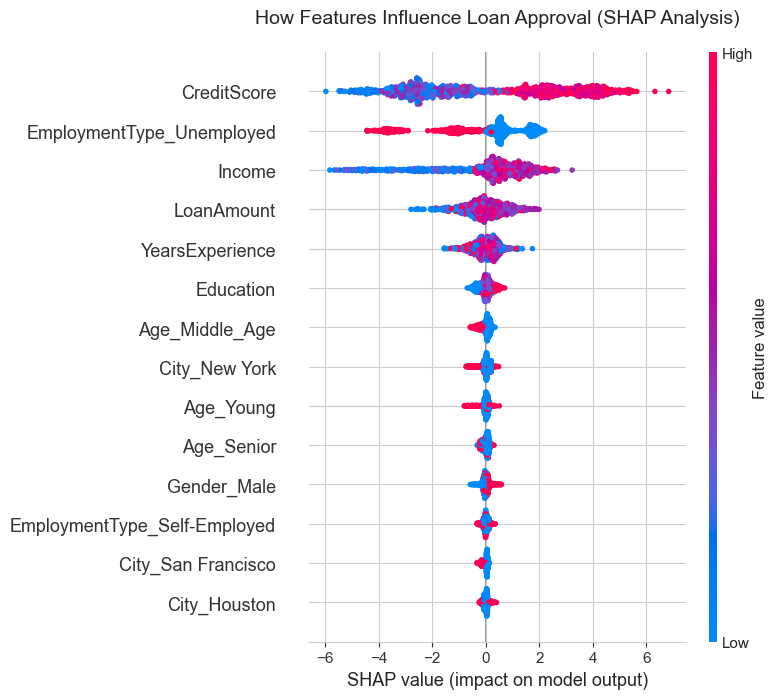

In [17]:
import shap

# Extract fitted preprocessor and trained model from the pipeline
preprocessor_fitted = best_model.named_steps['preprocessor']
lgbm_model = best_model.named_steps['classifier']

# Transform test data
X_test_transformed = preprocessor_fitted.transform(X_test)

# Convert sparse matrix to dense if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Retrieve feature names
num_cols = ['Income', 'CreditScore', 'LoanAmount', 'YearsExperience']
edu_cols = ['Education']

cat_onehot = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_cols = cat_onehot.get_feature_names_out(['Gender', 'City', 'EmploymentType'])

age_onehot = preprocessor_fitted.named_transformers_['age'].named_steps['onehot']
age_cols = age_onehot.get_feature_names_out(['Age'])

clean_feature_names = np.concatenate([num_cols, edu_cols, cat_cols, age_cols])

# Create DataFrame for SHAP compatibility
X_test_df = pd.DataFrame(X_test_transformed, columns=clean_feature_names)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_df)

# Handle SHAP output differences across versions
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

plt.figure(figsize=(10, 8))
plt.title("How Features Influence Loan Approval (SHAP Analysis)\n", fontsize=14)

shap.summary_plot(shap_vals_to_plot, X_test_df, show=False)

plt.tight_layout()
plt.show()

The model performs well, but my real question was: “What is it actually looking at when making decisions?” SHAP made this much clearer.

From the plot, CreditScore is clearly the dominant factor. As the score increases, the model leans toward approval; when it’s low, predictions quickly shift toward rejection. Being unemployed significantly lowers the approval probability as well. Income and loan amount matter too, but not as strongly as credit score.

What I like most is that the model’s behavior aligns with financial intuition. It’s not just producing good metrics — it’s making reasonable decisions.

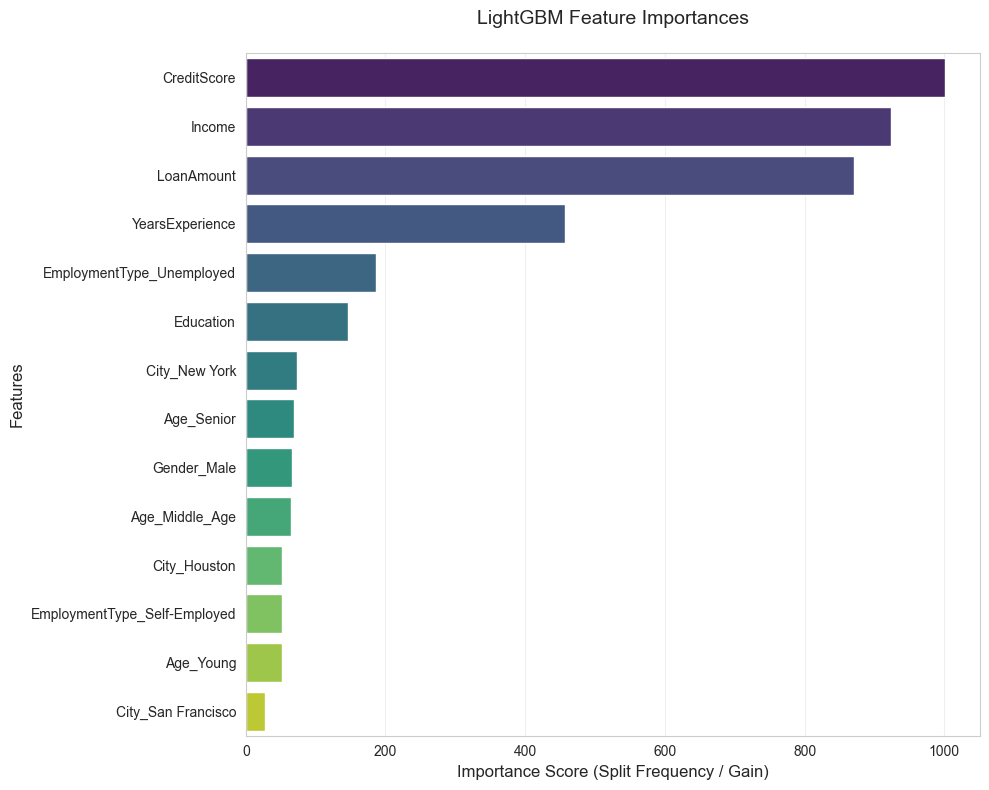

In [18]:
importances = lgbm_model.feature_importances_

# Assume 'clean_feature_names' is already defined from the SHAP step
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance Score': importances
})

# Sort from most important to least important
importance_df = importance_df.sort_values(by='Importance Score', ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance Score',
    y='Feature',
    data=importance_df,
    palette='viridis'
)

plt.title('LightGBM Feature Importances\n', fontsize=14)
plt.xlabel('Importance Score (Split Frequency / Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

After SHAP, I also looked at feature importances from the model’s own perspective. According to LightGBM, CreditScore is by far the most important feature. It’s followed by Income and LoanAmount.

This tells me the model is behaving in a financially reasonable way. Credit score, income, and loan amount are at the core of the decision process, while age groups, city, and gender play a much smaller role.

It’s reassuring to see that SHAP results and feature importances are consistent. The model is not only performing well but also making logically sound decisions.

In this project, my goal was not only to achieve strong performance but also to understand how the model makes decisions. I aimed to build a balanced, interpretable system aligned with financial logic from start to finish.

If you found this work helpful or interesting, feel free to leave an upvote 🙌

In [20]:
import joblib

# Cross-validation ile doğrulanmış EN İYİ modeli kaydediyoruz
best_model_to_deploy = random_search.best_estimator_

# Bu dosyayı Streamlit uygulamasında kullanacaksın
joblib.dump(best_model_to_deploy, 'best_credit_model.pkl')

['best_credit_model.pkl']